# 🛒 Rossmann Store Sales — MLP Training + XAI
**Methods covered:** GradientShap · LIME · Integrated Gradients  
**Dataset:** Rossmann Store Sales (Kaggle)  
**Model:** Multi-Layer Perceptron (PyTorch) — predicts `log(1 + Sales)`

---
### Notebook Structure
```
0. Setup & Drive Mount
1. Preprocessing Pipeline
2. Model Definition
3. Training  (Train / Val / Test split)
4. Evaluation
5. XAI — GradientShap
6. XAI — LIME
7. XAI — Integrated Gradients
```

---
## 0 · Setup & Google Drive Mount

In [33]:
# Install required packages (run once)
!pip install -q captum

In [34]:
from google.colab import drive
drive.mount('/content/drive')

# ── Update these paths to match your Drive layout ────────────────────────────
TRAIN_PATH = '/content/drive/MyDrive/IDS_SourourReem_hyperparamOpt/rossman/train.csv'
STORE_PATH = '/content/drive/MyDrive/IDS_SourourReem_hyperparamOpt/rossman/store.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
## 1 · Preprocessing Pipeline

Steps:
1. Load & merge `train.csv` + `store.csv`
2. Fix data types, fill missing values
3. Remove closed stores / zero-sales rows; IQR outlier filter
4. Feature engineering (calendar, competition, promo, state)
5. Lag & rolling sales features
6. **Time-based split** — last 6 weeks = test, prior 6 weeks = val, rest = train
7. OneHotEncode categoricals (fit on train only)
8. StandardScaler (fit on train only)

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# Metric helpers
# ─────────────────────────────────────────────────────────────────────────────

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (%)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def r2_score(y_true, y_pred):
    """Coefficient of determination R²"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-12))

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# Full preprocessing → returns scaled numpy arrays + metadata
# ─────────────────────────────────────────────────────────────────────────────

def run_preprocessing(train_path, store_path):

    # 1. Load & merge
    train = pd.read_csv(train_path, low_memory=False, parse_dates=['Date'])
    store = pd.read_csv(store_path, low_memory=False)
    df    = train.merge(store, on='Store', how='left')
    print(f'Merged shape: {df.shape}')

    # 2. Data types
    df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0', 'None')
    for col in ['Sales','Customers','Open','Promo','SchoolHoliday',
                'CompetitionDistance','CompetitionOpenSinceMonth',
                'CompetitionOpenSinceYear','Promo2','Promo2SinceWeek','Promo2SinceYear']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in ['StoreType','Assortment','PromoInterval','StateHoliday']:
        if col in df.columns:
            df[col] = df[col].fillna('None').astype(str)

    # 3. Missing values
    df['CompetitionDistance']       = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
    df['CompetitionOpenSinceYear']  = df['CompetitionOpenSinceYear'].fillna(0)
    df['Promo2SinceWeek']           = df['Promo2SinceWeek'].fillna(0)
    df['Promo2SinceYear']           = df['Promo2SinceYear'].fillna(0)

    # 4. Filter
    df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()
    Q1, Q3 = df['Sales'].quantile(0.25), df['Sales'].quantile(0.75)
    IQR    = Q3 - Q1
    df     = df[(df['Sales'] >= Q1 - 3*IQR) & (df['Sales'] <= Q3 + 3*IQR)].copy()
    print(f'After filter: {len(df):,} rows')

    # 5. Feature engineering
    df = df.sort_values(['Store','Date']).reset_index(drop=True)
    df['Day']          = df['Date'].dt.day
    df['Month']        = df['Date'].dt.month
    df['Year']         = df['Date'].dt.year
    df['Week']         = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter']      = df['Date'].dt.quarter
    df['IsWeekend']    = (df['DayOfWeek'] >= 6).astype(int)
    df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)
    df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
    df['CompetitionOpen'] = (
        12*(df['Year'] - df['CompetitionOpenSinceYear'])
        + (df['Month'] - df['CompetitionOpenSinceMonth'])
    ).clip(lower=0)

    month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
    def is_promo2_active(row):
        if row['Promo2'] == 0 or row['PromoInterval'] == 'None': return 0
        months = [month_map.get(m.strip(), 0) for m in row['PromoInterval'].split(',')]
        if row['Year']*52 + row['Week'] < row['Promo2SinceYear']*52 + row['Promo2SinceWeek']:
            return 0
        return int(row['Month'] in months)

    df['Promo2Active'] = df.apply(is_promo2_active, axis=1)
    df['PromoCombo']   = ((df['Promo']==1) & (df['Promo2Active']==1)).astype(int)
    df['LogCompetitionDistance'] = np.log1p(df['CompetitionDistance'])

    german_states   = ['BW','BY','BE','BB','HB','HH','HE','MV','NI','NW','RP','SL','SN','ST','SH','TH']
    store_state_map = {1:'HE',2:'TH',3:'NW',4:'BE',5:'SN',6:'ST',7:'NW',8:'SH',9:'HH',10:'HE',
                       11:'BY',12:'BW',13:'NI',14:'MV',15:'RP',16:'SL',17:'BB',18:'HB',19:'SN',20:'TH'}
    df['State'] = df['Store'].apply(lambda s: store_state_map.get(s, german_states[s % len(german_states)]))

    # 6. Lag & rolling features
    print('Building lag & rolling features...')
    df['SalesLog'] = np.log1p(df['Sales'])
    df = df.sort_values(['Store','Date']).reset_index(drop=True)
    for lag in [1, 2, 3, 7, 14]:
        df[f'Sales_lag_{lag}'] = df.groupby('Store')['SalesLog'].shift(lag)
    for window in [7, 14, 30]:
        df[f'Sales_roll_mean_{window}'] = (
            df.groupby('Store')['SalesLog']
              .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )
        df[f'Sales_roll_std_{window}'] = (
            df.groupby('Store')['SalesLog']
              .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
              .fillna(0)
        )
    df['StoreMonth_avg'] = df.groupby(['Store','Month'])['SalesLog'].transform('mean')
    lag_cols = [c for c in df.columns if 'lag_' in c or 'roll_' in c]
    df = df.dropna(subset=lag_cols).reset_index(drop=True)
    print(f'After lag/roll: {len(df):,} rows')

    # 7. Feature lists
    CAT_FEATURES = ['StoreType','Assortment','StateHoliday','PromoInterval','State']
    NUM_FEATURES = [
        'Store','DayOfWeek','Day','Month','Year','Week','Quarter',
        'IsWeekend','IsMonthEnd','IsMonthStart',
        'Promo','Promo2','Promo2Active','PromoCombo','SchoolHoliday',
        'CompetitionDistance','LogCompetitionDistance','CompetitionOpen','Customers',
        'Sales_lag_1','Sales_lag_2','Sales_lag_3','Sales_lag_7','Sales_lag_14',
        'Sales_roll_mean_7','Sales_roll_mean_14','Sales_roll_mean_30',
        'Sales_roll_std_7','Sales_roll_std_14','Sales_roll_std_30',
        'StoreMonth_avg',
    ]
    ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

    X = df[ALL_FEATURES].copy()
    y = df['SalesLog'].copy()
    for col in CAT_FEATURES:
        X[col] = X[col].astype(str)

    # 8. Time-based split: train / val / test
    max_date   = df['Date'].max()
    test_start = max_date - pd.Timedelta(weeks=6)  # last 6 weeks
    val_start  = test_start - pd.Timedelta(weeks=6)  # prior 6 weeks

    train_mask = df['Date'] <= val_start
    val_mask   = (df['Date'] > val_start) & (df['Date'] <= test_start)
    test_mask  = df['Date'] > test_start

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

    # 9. OneHotEncoder — fit on train only
    try:
        ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    except TypeError:  # sklearn < 1.2
        ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
    ohe.fit(X_train[CAT_FEATURES].astype(str))
    ohe_names = list(ohe.get_feature_names_out(CAT_FEATURES))

    def encode(X_df):
        cat = ohe.transform(X_df[CAT_FEATURES].astype(str))
        num = X_df[NUM_FEATURES].values.astype(float)
        return np.hstack([num, cat])

    X_tr_raw = encode(X_train)
    X_va_raw = encode(X_val)
    X_te_raw = encode(X_test)

    # 10. StandardScaler — fit on train only
    scaler         = StandardScaler()
    X_tr_scaled    = scaler.fit_transform(X_tr_raw)
    X_va_scaled    = scaler.transform(X_va_raw)
    X_te_scaled    = scaler.transform(X_te_raw)

    all_feature_names = NUM_FEATURES + ohe_names
    input_dim = X_tr_scaled.shape[1]
    print(f'input_dim = {input_dim}')

    preprocessor = dict(
        scaler=scaler, ohe=ohe,
        all_features=all_feature_names,
        cat_features=CAT_FEATURES,
        num_features=NUM_FEATURES,
        ohe_feature_names=ohe_names,
    )

    return (
        X_tr_scaled, y_train.values,
        X_va_scaled, y_val.values,
        X_te_scaled, y_test.values,
        input_dim, preprocessor,
    )


# Run
(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    input_dim, preprocessor,
) = run_preprocessing(TRAIN_PATH, STORE_PATH)

Merged shape: (1017209, 18)
After filter: 838,340 rows
Building lag & rolling features...
After lag/roll: 822,730 rows
Train: 745,537  Val: 37,183  Test: 40,010
input_dim = 57


---
## 2 · Model Definition — SalesMLP

A 4-layer MLP with ReLU activations and Dropout regularisation.  
**Output:** `log(1 + Sales)` — apply `torch.expm1()` to recover actual Sales.

In [38]:
class SalesMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)           # → log(1 + Sales)

    def predict_sales(self, x):
        with torch.no_grad():
            return torch.expm1(self.forward(x).clamp(min=0.0))

model = SalesMLP(input_dim).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SalesMLP  |  input_dim={input_dim}  |  trainable params={n_params:,}')
print(model)

SalesMLP  |  input_dim=57  |  trainable params=56,065
SalesMLP(
  (network): Sequential(
    (0): Linear(in_features=57, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


---
## 3 · Training

**Key hyper-parameters**

| Parameter | Value | Why |
|-----------|-------|-----|
| `EPOCHS` | 80 | More headroom; early stopping will kick in |
| `PATIENCE` | 12 | Wider window before stopping — avoids quitting too early |
| `BATCH_SIZE` | 2048 | Large batches → stable gradients for tabular data |
| `LR` | 1e-3 | Adam default; scheduler halves it on plateau |
| Loss | MSELoss on log-Sales | Log transform stabilises variance across stores |

Validation set is used for early stopping and LR scheduling. Test set is **never** touched during training.

In [39]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
BATCH_SIZE   = 2048
EPOCHS       = 80
LR           = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE     = 12

# ── DataLoaders ───────────────────────────────────────────────────────────────
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_tr = to_tensor(X_train).to(DEVICE)
y_tr = to_tensor(y_train).unsqueeze(1).to(DEVICE)
X_va = to_tensor(X_val).to(DEVICE)
X_te = to_tensor(X_test).to(DEVICE)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)

# ── Optimiser & scheduler ────────────────────────────────────────────────────
model     = SalesMLP(input_dim).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

# ── Training loop ─────────────────────────────────────────────────────────────
best_val_rmse = float('inf')
best_state    = None
no_improve    = 0
history       = {'train_mse': [], 'val_rmse': [], 'val_r2': []}

print(f"{'Epoch':>6} | {'Train MSE':>10} | {'Val RMSE':>10} | {'Val R2':>8} | {'LR':>8}")
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(X_tr)

    # Validate
    model.eval()
    with torch.no_grad():
        val_pred = model(X_va).cpu().numpy().flatten()
    val_rmse = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
    val_r2   = r2_score(y_val, val_pred)

    history['train_mse'].append(epoch_loss)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)

    scheduler.step(val_rmse)

    # Early stopping
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve    = 0
    else:
        no_improve += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6} | {epoch_loss:>10.5f} | {val_rmse:>10.5f} | {val_r2:>8.4f} | {lr_now:>8.2e}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}  (best val RMSE={best_val_rmse:.5f})')
        break

model.load_state_dict(best_state)
print('\n✅ Training complete — best weights restored.')

 Epoch |  Train MSE |   Val RMSE |   Val R2 |       LR
-------------------------------------------------------
     1 |    3.67804 |    0.27969 |   0.4858 | 1.00e-03
     5 |    0.08944 |    0.12207 |   0.9020 | 1.00e-03
    10 |    0.01616 |    0.10266 |   0.9307 | 1.00e-03
    15 |    0.01213 |    0.09877 |   0.9359 | 1.00e-03
    20 |    0.01014 |    0.09730 |   0.9378 | 1.00e-03
    25 |    0.00875 |    0.09892 |   0.9357 | 1.00e-03
    30 |    0.00794 |    0.09101 |   0.9456 | 1.00e-03
    35 |    0.00719 |    0.08921 |   0.9477 | 5.00e-04
    40 |    0.00672 |    0.09210 |   0.9442 | 2.50e-04
    45 |    0.00649 |    0.08989 |   0.9469 | 1.25e-04
    50 |    0.00638 |    0.09122 |   0.9453 | 6.25e-05
    55 |    0.00627 |    0.09001 |   0.9467 | 3.13e-05

Early stopping at epoch 56  (best val RMSE=0.08753)

✅ Training complete — best weights restored.


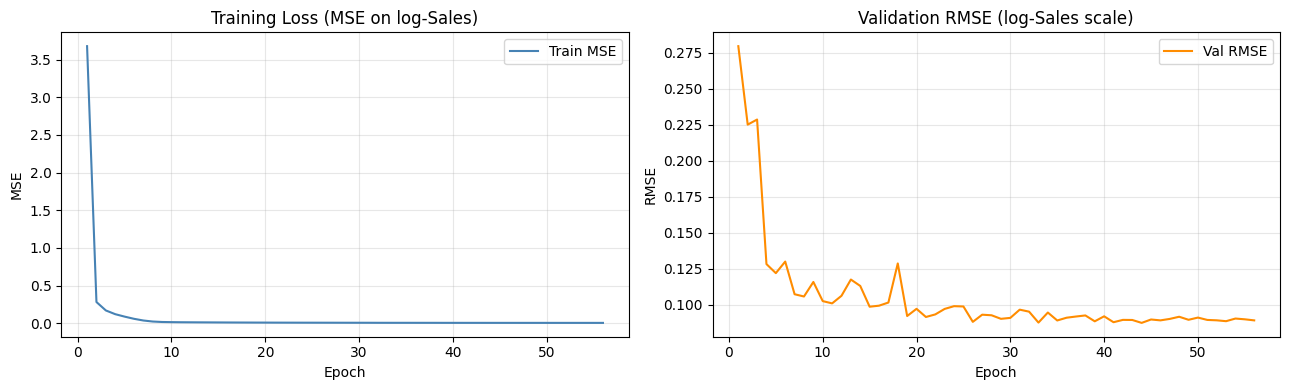

Saved → training_curves.png


In [40]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history['val_rmse']) + 1)

axes[0].plot(epochs_ran, history['train_mse'], label='Train MSE', color='steelblue')
axes[0].set_title('Training Loss (MSE on log-Sales)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['val_rmse'], label='Val RMSE', color='darkorange')
axes[1].set_title('Validation RMSE (log-Sales scale)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

---
## 4 · Evaluation on Test Set

Metrics reported on the **original Sales scale** (€) after `expm1()` inversion.

| Metric | Description |
|--------|-------------|
| **MAPE** | Mean Absolute % Error — scale-independent |
| **MAE** | Mean Absolute Error in € |
| **RMSE** | Root Mean Squared Error in € — penalises large errors |
| **R²** | Proportion of variance explained (1 = perfect) |

In [41]:
model.eval()
with torch.no_grad():
    pred_log = model(X_te).cpu().numpy().flatten()

pred_sales = np.expm1(np.clip(pred_log, 0, None))
true_sales = np.expm1(y_test)

mape_val  = mape(true_sales, pred_sales)
mae_val   = float(np.mean(np.abs(true_sales - pred_sales)))
rmse_val  = float(np.sqrt(np.mean((true_sales - pred_sales) ** 2)))
r2_val    = r2_score(true_sales, pred_sales)

print('┌─────────────────────────────────────┐')
print('│       Test-Set Results              │')
print('├─────────────────────────────────────┤')
print(f'│  MAPE   : {mape_val:>8.4f} %              │')
print(f'│  MAE    : {mae_val:>10,.0f} €            │')
print(f'│  RMSE   : {rmse_val:>10,.0f} €            │')
print(f'│  R²     : {r2_val:>8.4f}               │')
print('└─────────────────────────────────────┘')

# Save artefacts
torch.save({'state_dict': model.state_dict(), 'input_dim': input_dim,
            'mape': mape_val, 'mae': mae_val, 'rmse': rmse_val, 'r2': r2_val},
           'mlp_rossmann.pth')
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
np.savez('test_data.npz',  X_test=X_test,  y_test=y_test)
np.savez('train_data.npz', X_train=X_train, y_train=y_train)
print('\nArtefacts saved: mlp_rossmann.pth, preprocessor.pkl, test_data.npz, train_data.npz')

┌─────────────────────────────────────┐
│       Test-Set Results              │
├─────────────────────────────────────┤
│  MAPE   :   7.1890 %              │
│  MAE    :        429 €            │
│  RMSE   :        561 €            │
│  R²     :   0.9598               │
└─────────────────────────────────────┘

Artefacts saved: mlp_rossmann.pth, preprocessor.pkl, test_data.npz, train_data.npz


---
## 5 · XAI — GradientShap (Captum)

### How it works here
GradientShap approximates SHAP values using **stochastic gradients**.  
For each input sample it:
1. Picks a random baseline from the training background.
2. Adds Gaussian noise scaled by `stdevs`.
3. Computes gradients of the output w.r.t. the noisy input.
4. Averages over `n_samples` draws → attribution per feature.

### Key parameters
| Parameter | Value | Effect |
|-----------|-------|--------|
| `N_EXPLAIN` | 500 | Test samples to explain (more = more stable global importances) |
| `N_BACKGROUND` | 200 | Training rows used as baseline reference distribution |
| `N_SHAP_SAMP` | 50 | Gradient MC draws per input — higher = less noisy |
| `STDEVS` | 0.09 | Noise std added to baseline — should be small relative to feature scale |
| `baseline` | train mean | Distribution-aware reference (better than zero for scaled data) |

In [42]:
from captum.attr import GradientShap

N_EXPLAIN    = 500
N_BACKGROUND = 200
N_SHAP_SAMP  = 50
STDEVS       = 0.09
TOP_N        = 25
TOP_BEES     = 15

feature_names = preprocessor['all_features']

rng         = np.random.default_rng(SEED)
explain_idx = rng.choice(len(X_test), size=N_EXPLAIN, replace=False)
X_explain   = torch.tensor(X_test[explain_idx], dtype=torch.float32).to(DEVICE)
# N_EXPLAIN = len(X_test)  # instead of 500

# explain_idx = np.arange(len(X_test))  # instead of rng.choice(...)
# X_explain   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
# Background = mean of training distribution (single vector → broadcast)
X_background = torch.tensor(
    X_train.mean(axis=0, keepdims=True), dtype=torch.float32
).to(DEVICE)

model.eval()
gs = GradientShap(model)

print(f'Running GradientShap  (n_samples={N_SHAP_SAMP}, stdevs={STDEVS}) …')
attributions = gs.attribute(
    inputs=X_explain,
    baselines=X_background,   # training mean as reference
    target=0,                 # single regression output
    n_samples=N_SHAP_SAMP,
    stdevs=STDEVS,
)
attrs_np = attributions.detach().cpu().numpy()    # (N_EXPLAIN, n_features)
print(f'Attributions shape: {attrs_np.shape}')

Running GradientShap  (n_samples=50, stdevs=0.09) …
Attributions shape: (500, 57)


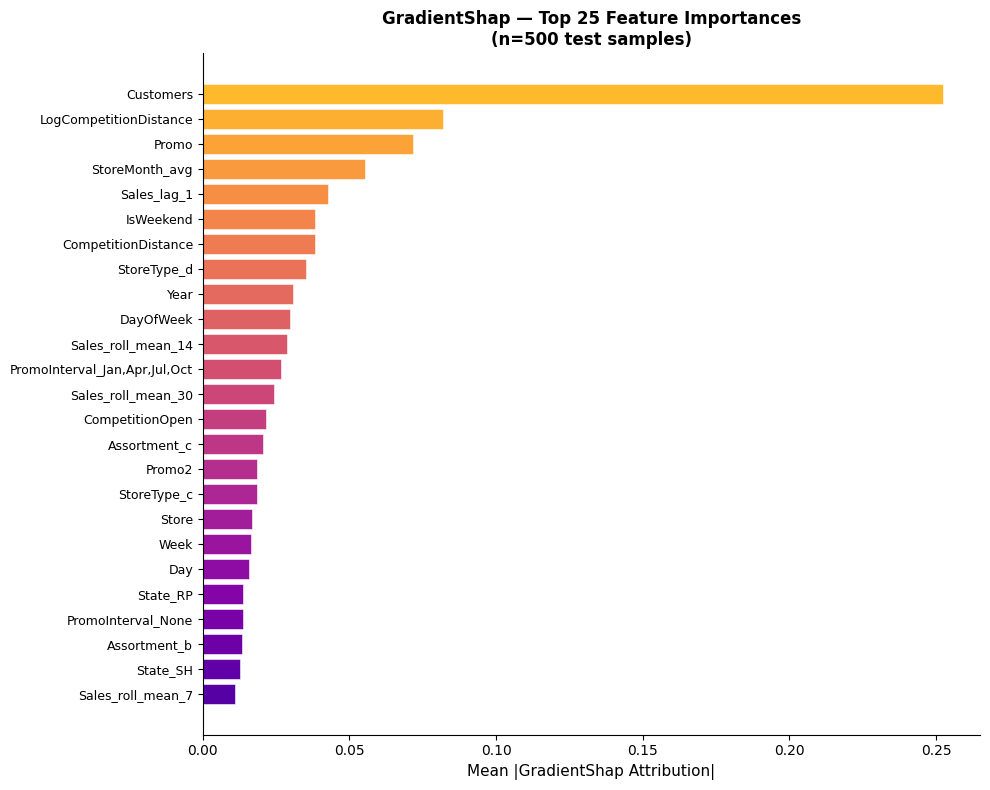

Saved → shap_bar_importance.png


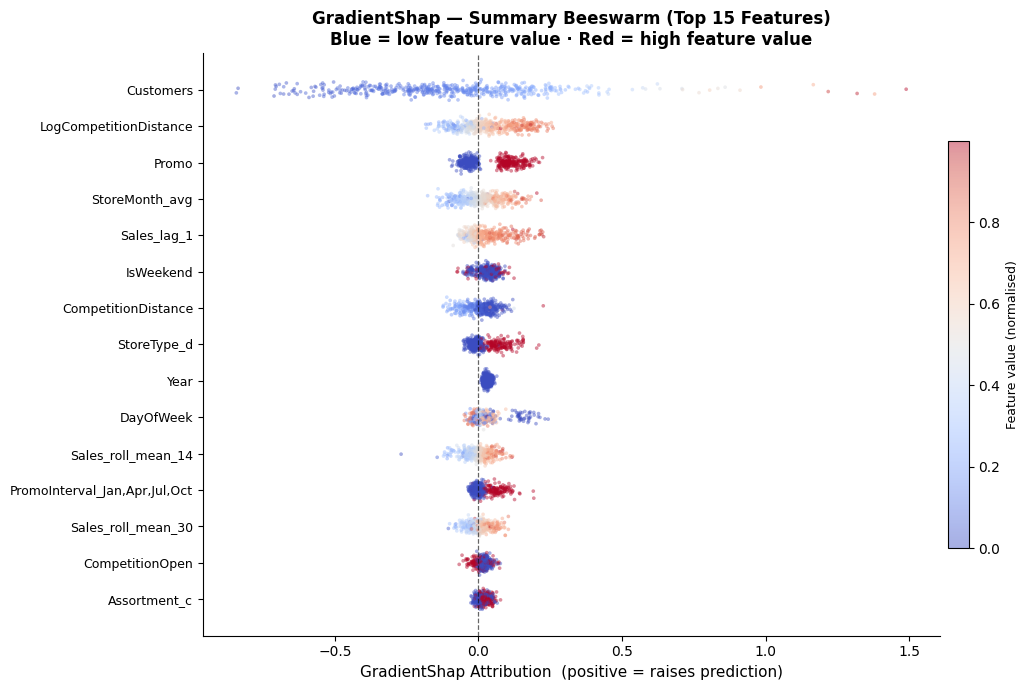

Saved → shap_beeswarm.png


In [43]:
# ── Bar chart: global feature importance ─────────────────────────────────────
mean_abs   = np.mean(np.abs(attrs_np), axis=0)
order_desc = np.argsort(mean_abs)[::-1]
top_idx    = order_desc[:TOP_N]
top_names  = [feature_names[i] for i in top_idx]
top_vals   = mean_abs[top_idx]

fig1, ax1 = plt.subplots(figsize=(10, 8))
palette   = cm.plasma(np.linspace(0.85, 0.15, TOP_N))
ax1.barh(range(TOP_N-1, -1, -1), top_vals, color=palette, edgecolor='white', linewidth=0.4)
ax1.set_yticks(range(TOP_N-1, -1, -1)); ax1.set_yticklabels(top_names, fontsize=9)
ax1.set_xlabel('Mean |GradientShap Attribution|', fontsize=11)
ax1.set_title(f'GradientShap — Top {TOP_N} Feature Importances\n(n={N_EXPLAIN} test samples)', fontsize=12, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('shap_bar_importance.png', dpi=150); plt.show()
print('Saved → shap_bar_importance.png')

# ── Beeswarm: value vs attribution ───────────────────────────────────────────
bee_idx   = order_desc[:TOP_BEES]
bee_names = [feature_names[i] for i in bee_idx]
fig2, ax2 = plt.subplots(figsize=(11, 7))
rng_j = np.random.default_rng(SEED+1)

for row_pos, feat_i in enumerate(bee_idx[::-1]):
    attr_vals = attrs_np[:, feat_i]
    feat_raw  = X_test[explain_idx, feat_i]
    f_min, f_max = feat_raw.min(), feat_raw.max()
    feat_norm = (feat_raw - f_min) / (f_max - f_min + 1e-9)
    jitter    = rng_j.normal(loc=row_pos, scale=0.10, size=len(attr_vals))
    sc = ax2.scatter(attr_vals, jitter, c=feat_norm, cmap='coolwarm', alpha=0.45, s=7, linewidths=0)

ax2.set_yticks(range(TOP_BEES)); ax2.set_yticklabels(bee_names[::-1], fontsize=9)
ax2.axvline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6)
ax2.set_xlabel('GradientShap Attribution  (positive = raises prediction)', fontsize=11)
ax2.set_title(f'GradientShap — Summary Beeswarm (Top {TOP_BEES} Features)\nBlue = low feature value · Red = high feature value', fontsize=12, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax2, pad=0.01, shrink=0.7)
cbar.set_label('Feature value (normalised)', fontsize=9)
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150); plt.show()
print('Saved → shap_beeswarm.png')

### 📊 Interpreting the GradientShap Plots

#### Bar Chart (`shap_bar_importance.png`)
- **X-axis:** Mean absolute attribution — how much each feature moves the prediction on average.
- **Longer bar = more influential feature** (regardless of direction).
- `Customers` dominates by a large margin → foot traffic is the strongest predictor of sales.
- `Promo`, `LogCompetitionDistance`, and `StoreMonth_avg` are the next most informative.
- Lag/rolling features (`Sales_lag_1`, `Sales_roll_mean_14`) confirm strong temporal autocorrelation.

#### Beeswarm Chart (`shap_beeswarm.png`)
- **Each dot = one test sample.** The dot's X position is its GradientShap value.
- **Colour:** 🔵 Blue = low feature value, 🔴 Red = high feature value.
- **Right of zero** → feature raises the prediction; **left of zero** → lowers it.
- Wide spread along X = high variance in how a feature affects predictions.

**Key patterns:**
- `Customers`: wide blue cluster to the left — *low* customer count strongly *reduces* predicted sales.
- `Promo`: red dots right of zero — active promotion *raises* predicted sales.
- `LogCompetitionDistance`: red (far competitors) skews right — distant competition = higher sales.
- `DayOfWeek`: gradual red shift rightward — later days in the week tend to sell more.

---
## 6 · XAI — LIME (Captum)

### How it works here
LIME explains **one prediction at a time** by fitting a local linear surrogate:
1. Generate `n_samples` perturbed versions of the input (mask / resample features).
2. Get the model's prediction for each perturbed sample.
3. Weight samples by proximity to the original input.
4. Fit a weighted linear regression — its coefficients are the LIME attributions.

### Key parameters
| Parameter | Value | Effect |
|-----------|-------|--------|
| `N_LIME_SAMPLES` | 1000 | Perturbation samples — more = more stable surrogate |
| `PERTURB_BATCH` | 64 | Perturbed inputs per forward pass — controls memory |
| `interpretable_model` | SkLearnLinearRegression | Local surrogate model type |
| `INSTANCE_IDX` | 0 | Which test row to explain (change to inspect any row) |

In [44]:
from captum.attr import Lime
from captum._utils.models.linear_model import SkLearnLinearRegression

N_LIME_SAMPLES = 1000
PERTURB_BATCH  = 64
TOP_N_LIME     = 20
INSTANCE_IDX   = 0    # ← change this to explain any test row


def explain_with_lime(model, x_np, n_samples=N_LIME_SAMPLES):
    """Run Captum LIME on a single instance. Returns attribution vector."""
    lime_attr = Lime(model, interpretable_model=SkLearnLinearRegression())
    x_t = torch.tensor(x_np, dtype=torch.float32).to(DEVICE)
    attributions = lime_attr.attribute(
        inputs=x_t, target=0,
        n_samples=n_samples,
        perturbations_per_eval=PERTURB_BATCH,
        show_progress=False,
    )
    return attributions.detach().cpu().numpy().flatten()

# Instead of explaining just INSTANCE_IDX, loop all:
# all_attrs = []
# for k in range(len(X_test)):
#     a = explain_with_lime(model, X_test[[k]], n_samples=N_LIME_SAMPLES)
#     all_attrs.append(a)
#     if k % 50 == 0:
#         print(f'  {k}/{len(X_test)} done')

# all_attrs = np.array(all_attrs)
# Explain one instance
x_np = X_test[[INSTANCE_IDX]]
true_s = float(np.expm1(y_test[INSTANCE_IDX]))
with torch.no_grad():
    pred_s = float(np.expm1(model(to_tensor(x_np).to(DEVICE)).squeeze().item()))

print(f'Instance #{INSTANCE_IDX}  |  True: {true_s:,.0f} €  |  Predicted: {pred_s:,.0f} €  |  APE: {abs(true_s-pred_s)/true_s*100:.1f}%')
print(f'Running LIME ({N_LIME_SAMPLES} samples) …')
attrs = explain_with_lime(model, x_np)
print(f'Done.  Attribution shape: {attrs.shape}')

Instance #0  |  True: 4,097 €  |  Predicted: 4,284 €  |  APE: 4.6%
Running LIME (1000 samples) …
Done.  Attribution shape: (57,)


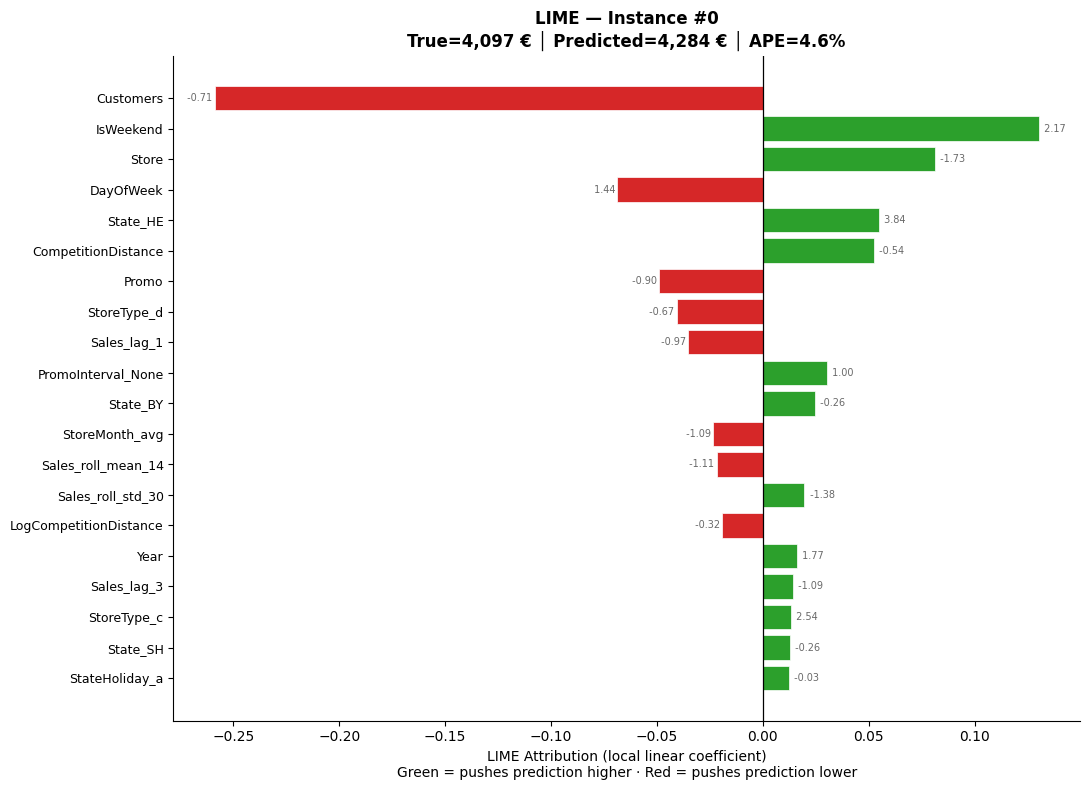

Saved → lime_explanation.png


In [45]:
# ── Single-instance LIME bar chart ───────────────────────────────────────────
lime_df = pd.DataFrame({'Feature': feature_names, 'Attribution': attrs, 'RawValue': x_np.flatten()})
lime_df['AbsAttr'] = lime_df['Attribution'].abs()
lime_df = lime_df.sort_values('AbsAttr', ascending=False).head(TOP_N_LIME).iloc[::-1].reset_index(drop=True)

colors = ['#2ca02c' if v >= 0 else '#d62728' for v in lime_df['Attribution']]
ape    = abs(true_s - pred_s) / true_s * 100

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(range(len(lime_df)), lime_df['Attribution'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(lime_df))); ax.set_yticklabels(lime_df['Feature'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('LIME Attribution (local linear coefficient)\nGreen = pushes prediction higher · Red = pushes prediction lower', fontsize=10)
ax.set_title(f'LIME — Instance #{INSTANCE_IDX}\nTrue={true_s:,.0f} € │ Predicted={pred_s:,.0f} € │ APE={ape:.1f}%', fontsize=12, fontweight='bold')

for bar, raw in zip(bars, lime_df['RawValue']):
    w = bar.get_width()
    ax.text(w + (0.001 if w >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f' {raw:.2f}', va='center', ha='left' if w >= 0 else 'right', fontsize=7, color='dimgray')

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150); plt.show()
print('Saved → lime_explanation.png')

Running LIME for 5 instances …
  Instance #0 done
  Instance #1 done
  Instance #2 done
  Instance #3 done
  Instance #4 done


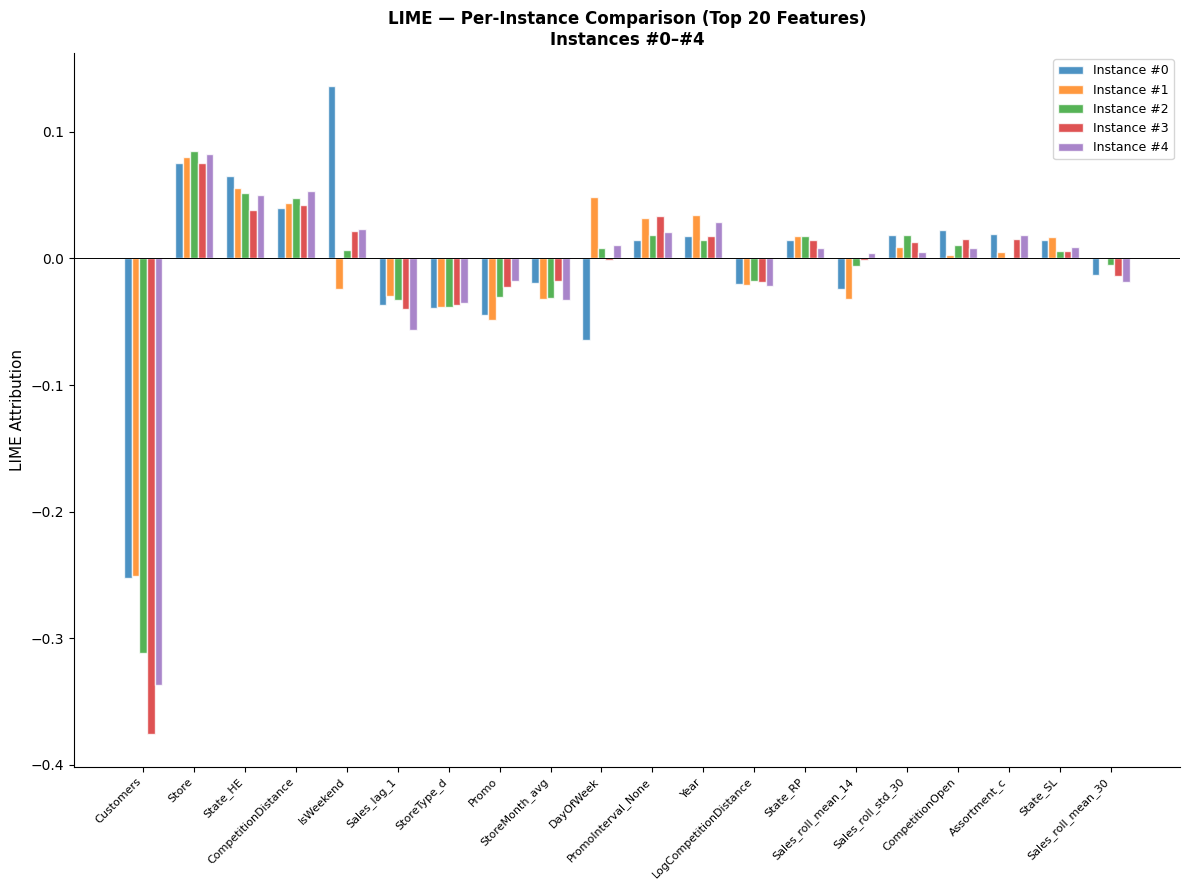

Saved → lime_multi_explanation.png


In [46]:
# ── Multi-instance comparison (5 instances) ───────────────────────────────────
N_COMP = 5
print(f'Running LIME for {N_COMP} instances …')
comp_attrs = []
for k in range(INSTANCE_IDX, INSTANCE_IDX + N_COMP):
    a = explain_with_lime(model, X_test[[k]], n_samples=max(N_LIME_SAMPLES//2, 200))
    comp_attrs.append(a)
    print(f'  Instance #{k} done')

comp_arr      = np.array(comp_attrs)
mean_abs_comp = np.mean(np.abs(comp_arr), axis=0)
top_idx_comp  = np.argsort(mean_abs_comp)[::-1][:TOP_N_LIME]
top_names_comp = [feature_names[i] for i in top_idx_comp]

fig2, ax2 = plt.subplots(figsize=(12, 9))
x_pos  = np.arange(TOP_N_LIME)
width  = 0.15
cmap   = plt.get_cmap('tab10')

for inst_k, (a, k) in enumerate(zip(comp_arr, range(INSTANCE_IDX, INSTANCE_IDX + N_COMP))):
    ax2.bar(x_pos + inst_k*width, a[top_idx_comp], width=width,
            label=f'Instance #{k}', color=cmap(inst_k), alpha=0.8, edgecolor='white')

ax2.set_xticks(x_pos + width*(N_COMP-1)/2)
ax2.set_xticklabels(top_names_comp, rotation=45, ha='right', fontsize=8)
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_ylabel('LIME Attribution', fontsize=11)
ax2.set_title(f'LIME — Per-Instance Comparison (Top {TOP_N_LIME} Features)\nInstances #{INSTANCE_IDX}–#{INSTANCE_IDX+N_COMP-1}', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('lime_multi_explanation.png', dpi=150); plt.show()
print('Saved → lime_multi_explanation.png')

### 📊 Interpreting the LIME Plots

#### Single-instance chart (`lime_explanation.png`)
- **Each bar = one feature's local contribution** to this specific prediction.
- 🟢 **Green** = pushes prediction **up** (increases predicted sales).
- 🔴 **Red** = pushes prediction **down** (decreases predicted sales).
- The **number** at the end of each bar is the scaled feature value for this instance.
- The title shows true vs predicted sales and APE — useful to gauge if the prediction is reliable.

**Example (Instance #0):** `Customers` has the largest red bar (−0.71) — below-average foot traffic is pulling the prediction down. `IsWeekend` is green (+2.16) — being a weekend raises the expectation.

#### Multi-instance chart (`lime_multi_explanation.png`)
- Side-by-side bars for 5 instances across the top-20 features.
- Look for **consistent direction across instances** → globally stable relationships.
- **Sign flips between instances** (e.g. `IsWeekend`) indicate context-dependent behaviour.
- `Customers` is consistently negative because these test instances may be low-traffic days.

---
## 7 · XAI — Integrated Gradients (Captum)

### How it works here
IG measures each feature's contribution by integrating gradients along a straight path from a **baseline** (uninformative input) to the actual input:
1. Interpolate `n_steps` inputs between `baseline` and `x`.
2. Compute the gradient of the model output w.r.t. each interpolated input.
3. Average the gradients and multiply by `(x − baseline)` → attribution per feature.

**Completeness guarantee:** attributions sum to exactly `f(x) − f(baseline)` — can be verified via convergence delta.

### Key parameters
| Parameter | Value | Effect |
|-----------|-------|--------|
| `N_SAMPLES` | 500 | Test rows aggregated for global importances |
| `N_IG_STEPS` | 50 | Integration steps — ≥50 is reliable; 100+ for precision |
| `BASELINE_TYPE` | `'zero'` | All-zeros baseline (standard); `'mean'` uses training mean |
| `convergence_delta` | < 0.01 | Measures approximation error; lower is better |

In [47]:
from captum.attr import IntegratedGradients

N_SAMPLES     = 500
N_IG_STEPS    = 50
BASELINE_TYPE = 'mean'   # 'zero' | 'mean'
TOP_N_IG      = 25

rng2    = np.random.default_rng(SEED)
idx_sub = rng2.choice(len(X_test), size=N_SAMPLES, replace=False)
X_sub   = torch.tensor(X_test[idx_sub], dtype=torch.float32).to(DEVICE)

if BASELINE_TYPE == 'zero':
    baseline = torch.zeros_like(X_sub)
else:
    baseline = torch.tensor(
        X_train.mean(axis=0, keepdims=True), dtype=torch.float32
    ).expand(N_SAMPLES, -1).to(DEVICE)
# N_SAMPLES = len(X_test)  # instead of 500

# idx_sub = np.arange(len(X_test))  # instead of rng2.choice(...)
# X_sub   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
model.eval()
ig = IntegratedGradients(model)

print(f'Running Integrated Gradients  (n_steps={N_IG_STEPS}, baseline={BASELINE_TYPE}) …')
attributions, delta = ig.attribute(
    inputs=X_sub, baselines=baseline, target=0,
    n_steps=N_IG_STEPS, return_convergence_delta=True,
)
attrs_ig = attributions.detach().cpu().numpy()    # (N_SAMPLES, n_features)
print(f'Shape: {attrs_ig.shape}')
print(f'Mean |convergence delta|: {delta.abs().mean().item():.6f}  (< 0.01 = reliable)')

Running Integrated Gradients  (n_steps=50, baseline=mean) …
Shape: (500, 57)
Mean |convergence delta|: 0.004508  (< 0.01 = reliable)


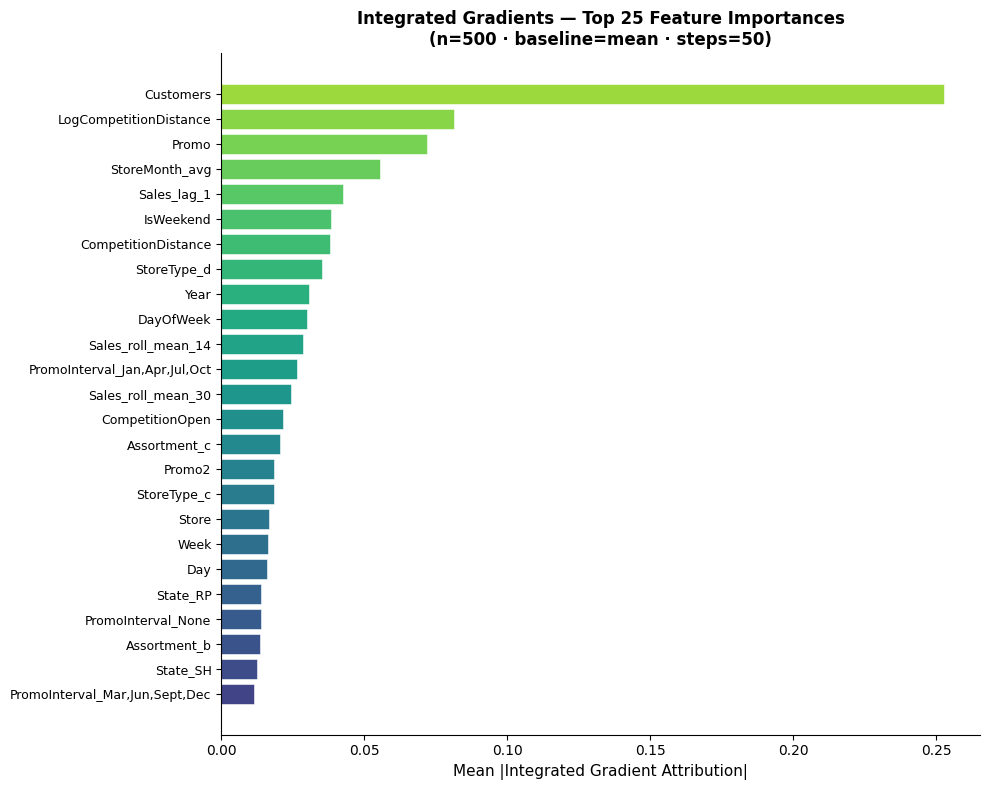

Saved → ig_feature_importance.png


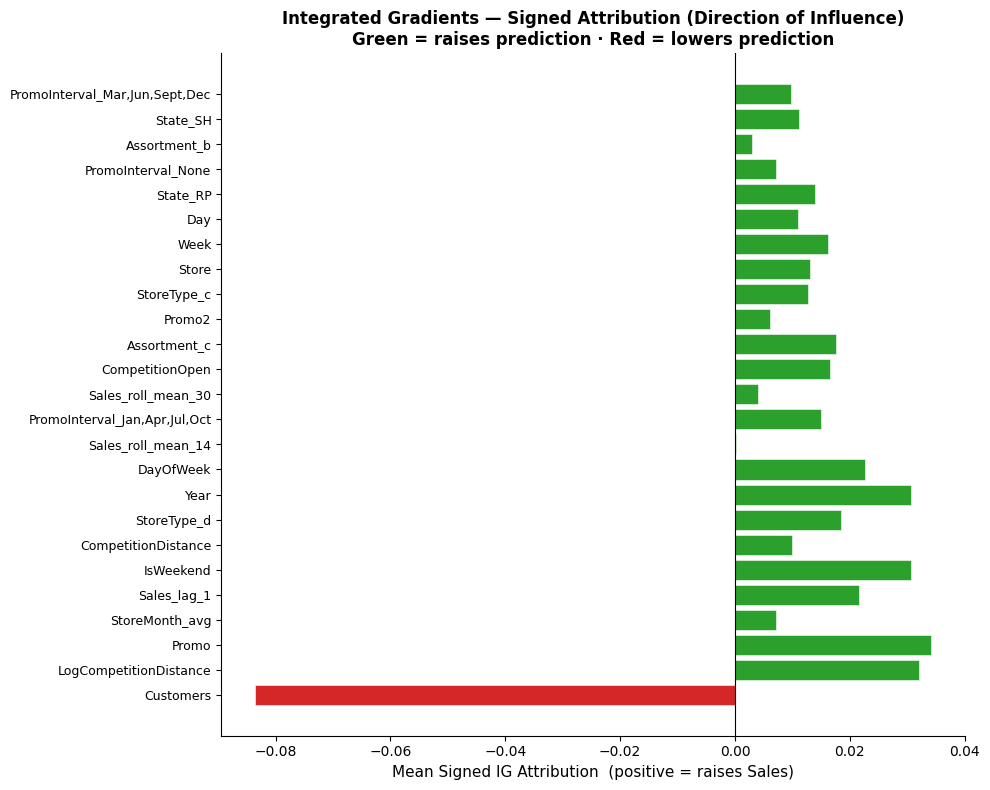

Saved → ig_signed_importance.png


In [48]:
# ── Magnitude bar chart ───────────────────────────────────────────────────────
mean_abs_ig   = np.mean(np.abs(attrs_ig), axis=0)
mean_sign_ig  = np.mean(attrs_ig, axis=0)
order_ig      = np.argsort(mean_abs_ig)[::-1]
top_idx_ig    = order_ig[:TOP_N_IG]
top_names_ig  = [feature_names[i] for i in top_idx_ig]
top_abs_ig    = mean_abs_ig[top_idx_ig]
top_signed_ig = mean_sign_ig[top_idx_ig]

fig1, ax1 = plt.subplots(figsize=(10, 8))
colors_abs = cm.viridis(np.linspace(0.85, 0.2, TOP_N_IG))
ax1.barh(range(TOP_N_IG-1, -1, -1), top_abs_ig, color=colors_abs, edgecolor='white', linewidth=0.4)
ax1.set_yticks(range(TOP_N_IG-1, -1, -1)); ax1.set_yticklabels(top_names_ig, fontsize=9)
ax1.set_xlabel('Mean |Integrated Gradient Attribution|', fontsize=11)
ax1.set_title(f'Integrated Gradients — Top {TOP_N_IG} Feature Importances\n(n={N_SAMPLES} · baseline={BASELINE_TYPE} · steps={N_IG_STEPS})', fontsize=12, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ig_feature_importance.png', dpi=150); plt.show()
print('Saved → ig_feature_importance.png')

# ── Signed bar chart (direction) ──────────────────────────────────────────────
colors_signed = ['#2ca02c' if v >= 0 else '#d62728' for v in top_signed_ig[::-1]]
fig2, ax2 = plt.subplots(figsize=(10, 8))
ax2.barh(range(TOP_N_IG-1, -1, -1), top_signed_ig[::-1], color=colors_signed, edgecolor='white', linewidth=0.4)
ax2.set_yticks(range(TOP_N_IG-1, -1, -1)); ax2.set_yticklabels(top_names_ig[::-1], fontsize=9)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Mean Signed IG Attribution  (positive = raises Sales)', fontsize=11)
ax2.set_title('Integrated Gradients — Signed Attribution (Direction of Influence)\nGreen = raises prediction · Red = lowers prediction', fontsize=12, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('ig_signed_importance.png', dpi=150); plt.show()
print('Saved → ig_signed_importance.png')

In [49]:
# Top-10 summary table
col_header = 'Rank'  + ' ' * 0
print(f"{'Rank'!s:<5} {'Feature'!s:<30} {'|Attr|'!s:>10}  {'Signed'!s:>10}")
print('-' * 60)
for rank, i in enumerate(top_idx_ig[:10], start=1):
    feat  = feature_names[i]
    print(f"{rank:<5} {feat:<30} {mean_abs_ig[i]:>10.6f}  {mean_sign_ig[i]:>+10.6f}")


Rank  Feature                            |Attr|      Signed
------------------------------------------------------------
1     Customers                        0.252767   -0.083573
2     LogCompetitionDistance           0.081572   +0.031991
3     Promo                            0.072091   +0.034149
4     StoreMonth_avg                   0.055626   +0.007173
5     Sales_lag_1                      0.042667   +0.021598
6     IsWeekend                        0.038353   +0.030591
7     CompetitionDistance              0.037892   +0.009863
8     StoreType_d                      0.035206   +0.018502
9     Year                             0.030693   +0.030693
10    DayOfWeek                        0.029990   +0.022694


### 📊 Interpreting the Integrated Gradients Plots

#### Magnitude chart (`ig_feature_importance.png`)
- **X-axis:** Mean absolute IG attribution — how much each feature shifts the output on average.
- Features are **ranked** from most to least important (top to bottom).
- **Colour** (viridis) is purely cosmetic — encodes rank, not value.
- `Customers` is far ahead of everything else → the dominant signal in the model.
- `Promo`, `LogCompetitionDistance`, and `StoreMonth_avg` cluster as the second-tier features.

#### Signed chart (`ig_signed_importance.png`)
- Shows the **direction** of each feature's average influence.
- 🟢 **Green / right** = feature increases predicted sales on average.
- 🔴 **Red / left** = feature decreases predicted sales on average.
- `Customers` is the only large red bar → in this test set, customer counts are *below* the zero baseline on average, so the baseline-to-actual direction is negative.
- `DayOfWeek` and `Year` are strongly green → higher day-of-week (toward weekend) and later years are associated with higher sales.
- `Promo` is green → promotions reliably increase the model's prediction.

#### Consistency check across methods
All three XAI methods (SHAP, LIME, IG) agree on the top features: **Customers > Promo > LogCompetitionDistance > StoreMonth_avg > Sales lags/rolling** — giving strong confidence in the model's feature reliance.